In [6]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

print("Libraries loaded.")

Libraries loaded.


In [7]:
# 数据路径：优先 tempo 清洗结果
path_tempo = Path(r"D:\Downloads\FYP CHINA\data\tempo\master_daily.csv")
path_old = Path(r"D:\Downloads\FYP CHINA\data\master_daily.csv")

if path_tempo.exists():
    data_path = path_tempo
elif path_old.exists():
    data_path = path_old
else:
    raise FileNotFoundError("未找到 master_daily.csv（tempo 与 old 均不存在）")

print("Using dataset:", data_path)

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["city", "date", "AQI"]).copy()
df["AQI"] = pd.to_numeric(df["AQI"], errors="coerce")
df = df.dropna(subset=["AQI"])

print("Shape:", df.shape)
print("Cities:", df["city"].nunique())
print("Date range:", df["date"].min().date(), "~", df["date"].max().date())

display(df.head())

Using dataset: D:\Downloads\FYP CHINA\data\tempo\master_daily.csv
Shape: (258219, 9)
Cities: 138
Date range: 2020-01-01 ~ 2025-09-20


,city,date,AQI,PM2.5,PM10,SO2,NO2,CO,O3
0,七台河,2020-01-01,63.625000,41.875000,64.458333,15.541667,38.291667,0.737500,40.000000
1,七台河,2020-01-02,41.166667,25.791667,36.291667,11.958333,50.583333,0.775000,43.000000
2,七台河,2020-01-03,75.000000,54.750000,73.000000,22.166667,62.958333,1.075000,39.875000
3,七台河,2020-01-04,135.208333,103.250000,124.833333,23.458333,76.958333,1.300000,30.666667
4,七台河,2020-01-05,90.416667,67.041667,84.291667,18.625000,69.291667,1.133333,37.083333


City: 北京
Total rows: 2,090
Train rows: 1,672
Test rows: 418
Train date: 2020-01-01 ~ 2024-07-29
Test  date: 2024-07-30 ~ 2025-09-20


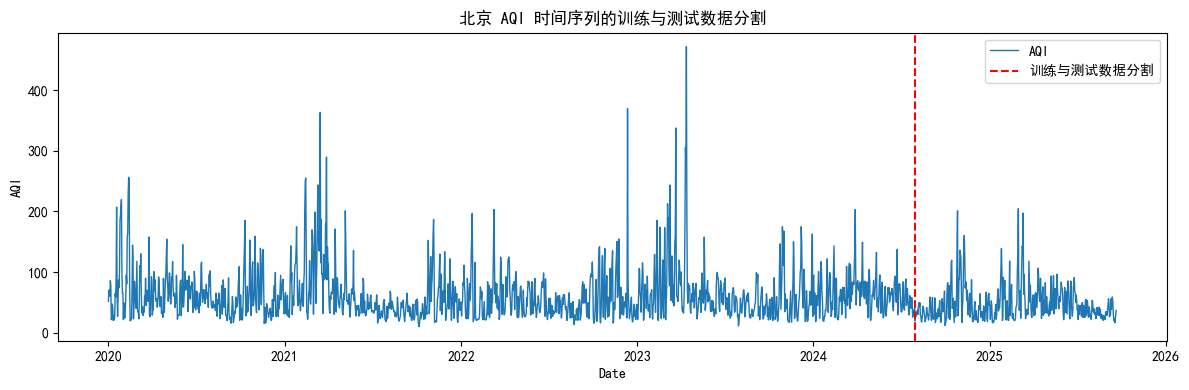

In [8]:
# 选择一个城市做展示（答辩可改）
CITY = "北京"
TEST_RATIO = 0.2

city_df = df[df["city"] == CITY].copy().sort_values("date")
if city_df.empty:
    raise ValueError(f"城市 {CITY} 在数据中不存在")

# 如果数据里同一城市同一天有重复记录，先取均值
city_df = city_df.groupby("date", as_index=False)["AQI"].mean()
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use a font that supports Chinese
plt.rcParams['axes.unicode_minus'] = False   # Correctly display minus signs

split_idx = int(len(city_df) * (1 - TEST_RATIO))
train_df = city_df.iloc[:split_idx].copy()
test_df = city_df.iloc[split_idx:].copy()

print(f"City: {CITY}")
print(f"Total rows: {len(city_df):,}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Train date: {train_df['date'].min().date()} ~ {train_df['date'].max().date()}")
print(f"Test  date: {test_df['date'].min().date()} ~ {test_df['date'].max().date()}")

plt.figure(figsize=(12, 4))
plt.plot(city_df["date"], city_df["AQI"], label="AQI", linewidth=1)
plt.axvline(train_df["date"].max(), color="red", linestyle="--", label="训练与测试数据分割")
plt.title(f"{CITY} AQI 时间序列的训练与测试数据分割")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# 训练 Prophet 模型
prophet_train = train_df.rename(columns={"date": "ds", "AQI": "y"}).copy()
prophet_test = test_df.rename(columns={"date": "ds", "AQI": "y"}).copy()

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
)
m.fit(prophet_train)

future = m.make_future_dataframe(periods=len(prophet_test), freq="D", include_history=True)
forecast = m.predict(future)

prophet_pred = forecast["yhat"].iloc[-len(prophet_test):].values
prophet_true = prophet_test["y"].values

print("Prophet training done.")
print("Forecast rows:", len(forecast))

16:54:52 - cmdstanpy - INFO - Chain [1] start processing
16:54:52 - cmdstanpy - INFO - Chain [1] done processing


Prophet training done.
Forecast rows: 2090


In [5]:
# 基线模型：移动平均、线性回归（用于对比）
# 1）移动平均基线：用训练集最后 7 天均值预测测试集
ma_window = 7
ma_value = train_df["AQI"].tail(ma_window).mean()
ma_pred = np.full(shape=len(test_df), fill_value=ma_value)

# 2）线性回归基线
lr_train = train_df.copy()
lr_test = test_df.copy()

origin_date = city_df["date"].min()
lr_train["t"] = (lr_train["date"] - origin_date).dt.days
lr_test["t"] = (lr_test["date"] - origin_date).dt.days

lr = LinearRegression()
lr.fit(lr_train[["t"]], lr_train["AQI"])
lr_pred = lr.predict(lr_test[["t"]])

# 评估函数
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

rows = []
for name, pred in [
    ("Prophet", prophet_pred),
    ("移动平均（7天）", ma_pred),
    ("线性回归", lr_pred),
]:
    mae, rmse, r2 = eval_metrics(test_df["AQI"].values, pred)
    rows.append({"模型": name, "MAE": mae, "RMSE": rmse, "R²": r2})

metrics_df = pd.DataFrame(rows).sort_values("RMSE")
display(metrics_df)

best_model = metrics_df.iloc[0]["模型"]
print("按 RMSE 最优模型：", best_model)

,模型,MAE,RMSE,R²
0,Prophet,20.603360,27.255369,0.125876
1,移动平均（7天）,20.022530,30.547431,-0.098041
2,线性回归,24.921562,30.975768,-0.129050


按 RMSE 最优模型： Prophet


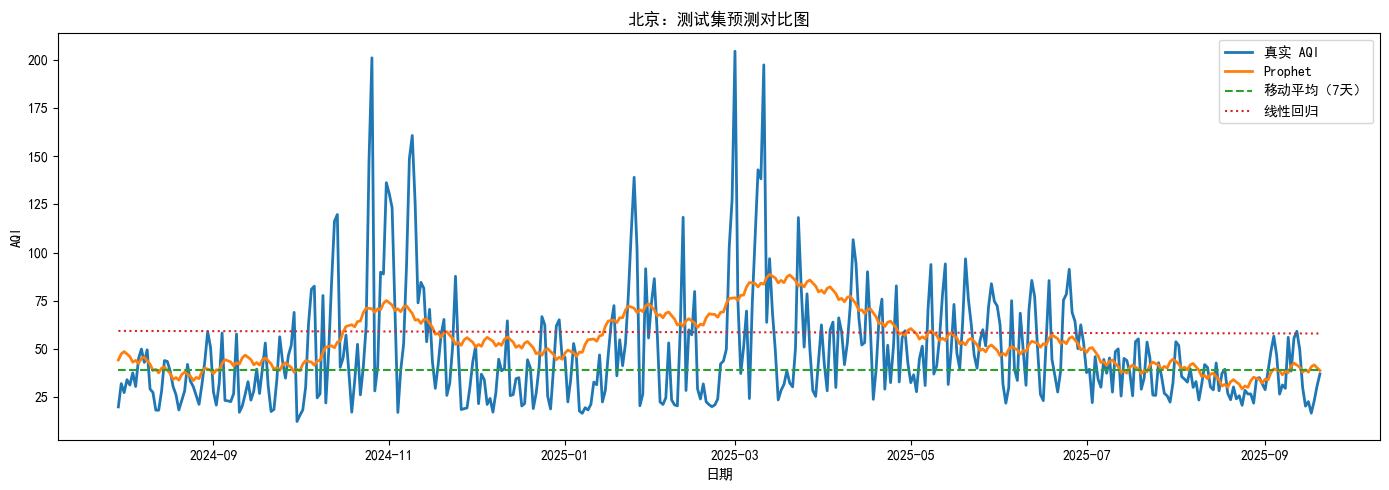

In [10]:
# 可视化：测试集真实值 vs 各模型预测（答辩核心截图）
plot_df = test_df[["date", "AQI"]].copy()
plot_df["Prophet"] = prophet_pred
plot_df["MovingAverage7d"] = ma_pred
plot_df["LinearRegression"] = lr_pred
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use a font that supports Chinese
plt.rcParams['axes.unicode_minus'] = False   # Correctly display minus signs

plt.figure(figsize=(14, 5))
plt.plot(plot_df["date"], plot_df["AQI"], label="真实 AQI", linewidth=2)
plt.plot(plot_df["date"], plot_df["Prophet"], label="Prophet", linewidth=2)
plt.plot(plot_df["date"], plot_df["MovingAverage7d"], label="移动平均（7天）", linestyle="--")
plt.plot(plot_df["date"], plot_df["LinearRegression"], label="线性回归", linestyle=":")
plt.title(f"{CITY}：测试集预测对比图")
plt.xlabel("日期")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# 保存训练输出（指标 + 测试集预测 + 未来30天预测）
out_dir = Path(r"D:\Downloads\FYP CHINA\data\tempo\model_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

# 指标
time_tag = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
metrics_path = out_dir / f"{CITY}_metrics_{time_tag}.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")

# 测试集预测
test_pred_path = out_dir / f"{CITY}_test_predictions_{time_tag}.csv"
plot_df.to_csv(test_pred_path, index=False, encoding="utf-8-sig")

# 未来30天预测（基于全量 city_df 重新训练 Prophet）
all_prophet_df = city_df.rename(columns={"date": "ds", "AQI": "y"})
final_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, changepoint_prior_scale=0.05)
final_model.fit(all_prophet_df)
future_30 = final_model.make_future_dataframe(periods=30, freq="D")
future_30_fc = final_model.predict(future_30).tail(30)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
future_30_path = out_dir / f"{CITY}_future30_{time_tag}.csv"
future_30_fc.to_csv(future_30_path, index=False, encoding="utf-8-sig")

print("Saved files:")
print("-", metrics_path)
print("-", test_pred_path)
print("-", future_30_path)

display(future_30_fc.head())

16:55:06 - cmdstanpy - INFO - Chain [1] start processing
16:55:06 - cmdstanpy - INFO - Chain [1] done processing


Saved files:
- D:\Downloads\FYP CHINA\data\tempo\model_outputs\北京_metrics_20260424_165505.csv
- D:\Downloads\FYP CHINA\data\tempo\model_outputs\北京_test_predictions_20260424_165505.csv
- D:\Downloads\FYP CHINA\data\tempo\model_outputs\北京_future30_20260424_165505.csv


,ds,yhat,yhat_lower,yhat_upper
2090,2025-09-21,28.916327,-21.164201,76.295751
2091,2025-09-22,29.020057,-17.284488,73.419036
2092,2025-09-23,27.890820,-21.342495,75.634354
2093,2025-09-24,30.737314,-15.292714,75.285258
2094,2025-09-25,31.854997,-16.687551,79.727767


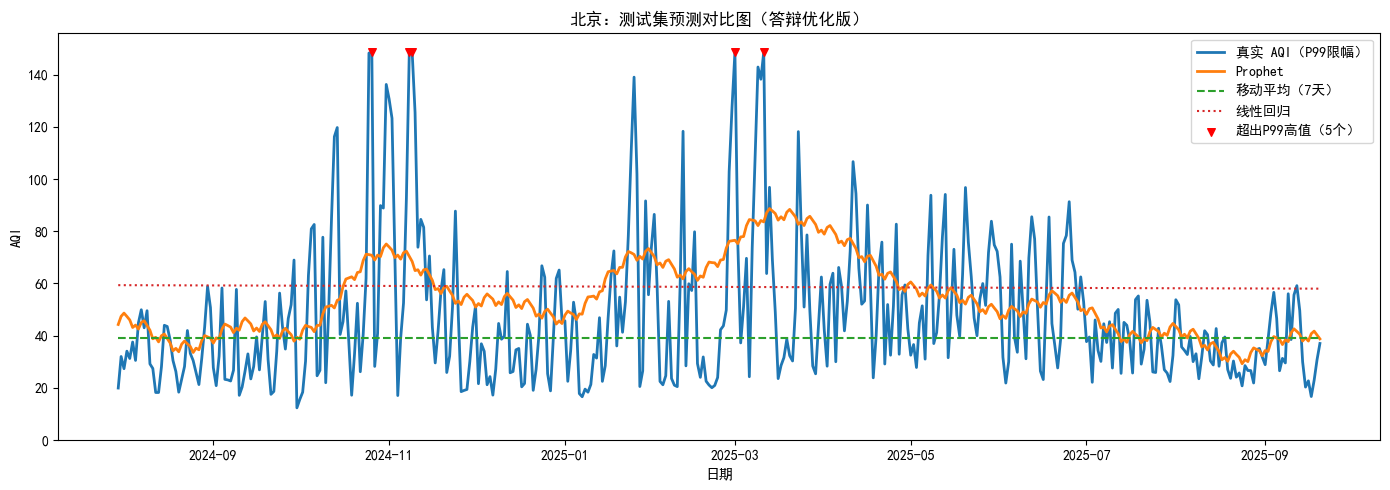

说明：显示上限采用真实AQI的P99=148.63，用于减弱极端峰值对整体趋势判断的干扰。


In [ ]:
# 可视化优化：P99限幅展示（保留高峰信息，避免主趋势被压扁）
plot_df = test_df[["date", "AQI"]].copy()
plot_df["Prophet"] = prophet_pred
plot_df["MovingAverage7d"] = ma_pred
plot_df["LinearRegression"] = lr_pred

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 用真实 AQI 的 P99 作为展示上限
upper_cap = float(plot_df["AQI"].quantile(0.99))
outlier_mask = plot_df["AQI"] > upper_cap
outlier_count = int(outlier_mask.sum())

plot_show = plot_df.copy()
for c in ["AQI", "Prophet", "MovingAverage7d", "LinearRegression"]:
    plot_show[c] = plot_show[c].clip(upper=upper_cap)

plt.figure(figsize=(14, 5))
plt.plot(plot_show["date"], plot_show["AQI"], label="真实 AQI（P99限幅）", linewidth=2)
plt.plot(plot_show["date"], plot_show["Prophet"], label="Prophet", linewidth=2)
plt.plot(plot_show["date"], plot_show["MovingAverage7d"], label="移动平均（7天）", linestyle="--")
plt.plot(plot_show["date"], plot_show["LinearRegression"], label="线性回归", linestyle=":")

# 标记被限幅的高峰点（不隐藏）
if outlier_count > 0:
    plt.scatter(
        plot_df.loc[outlier_mask, "date"],
        [upper_cap] * outlier_count,
        color="red",
        marker="v",
        s=30,
        label=f"超出P99高值（{outlier_count}个）",
        zorder=5,
    )

plt.ylim(0, upper_cap * 1.05)
plt.title(f"{CITY}：测试集预测对比图（答辩优化版）")
plt.xlabel("日期")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

print(f"说明：显示上限采用真实AQI的P99={upper_cap:.2f}，用于减弱极端峰值对整体趋势判断的干扰。")

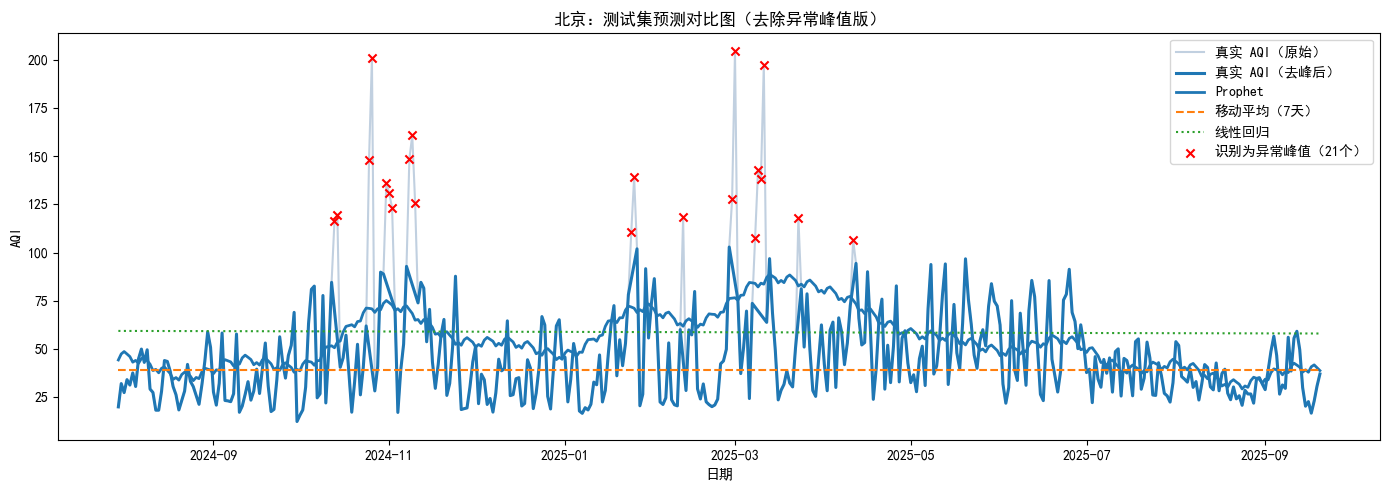

IQR上阈值=104.90，识别并处理的异常峰值数量=21。


In [13]:
# 峰值去除版（新行）：去除异常高峰后再展示
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = test_df[["date", "AQI"]].copy()
plot_df["Prophet"] = prophet_pred
plot_df["MovingAverage7d"] = ma_pred
plot_df["LinearRegression"] = lr_pred

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 1) 用 IQR 识别异常高峰（仅处理真实AQI）
q1 = plot_df["AQI"].quantile(0.25)
q3 = plot_df["AQI"].quantile(0.75)
iqr = q3 - q1
high_thr = q3 + 1.5 * iqr

peak_mask = plot_df["AQI"] > high_thr
peak_count = int(peak_mask.sum())

# 2) 将高峰置为空，再按时间插值，避免突刺
plot_df["AQI_denoised"] = plot_df["AQI"].copy()
plot_df.loc[peak_mask, "AQI_denoised"] = np.nan
plot_df["AQI_denoised"] = plot_df["AQI_denoised"].interpolate(method="linear").bfill().ffill()

# 3) 可视化：原始 vs 去峰后 + 模型曲线
plt.figure(figsize=(14, 5))
plt.plot(plot_df["date"], plot_df["AQI"], label="真实 AQI（原始）", color="#4e79a7", alpha=0.35, linewidth=1.5)
plt.plot(plot_df["date"], plot_df["AQI_denoised"], label="真实 AQI（去峰后）", color="#1f77b4", linewidth=2.2)
plt.plot(plot_df["date"], plot_df["Prophet"], label="Prophet", linewidth=2)
plt.plot(plot_df["date"], plot_df["MovingAverage7d"], label="移动平均（7天）", linestyle="--")
plt.plot(plot_df["date"], plot_df["LinearRegression"], label="线性回归", linestyle=":")

# 把被识别的峰值打点标出，方便答辩解释
if peak_count > 0:
    plt.scatter(
        plot_df.loc[peak_mask, "date"],
        plot_df.loc[peak_mask, "AQI"],
        color="red",
        marker="x",
        s=35,
        label=f"识别为异常峰值（{peak_count}个）",
        zorder=5,
    )

plt.title(f"{CITY}：测试集预测对比图（去除异常峰值版）")
plt.xlabel("日期")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

print(f"IQR上阈值={high_thr:.2f}，识别并处理的异常峰值数量={peak_count}。")

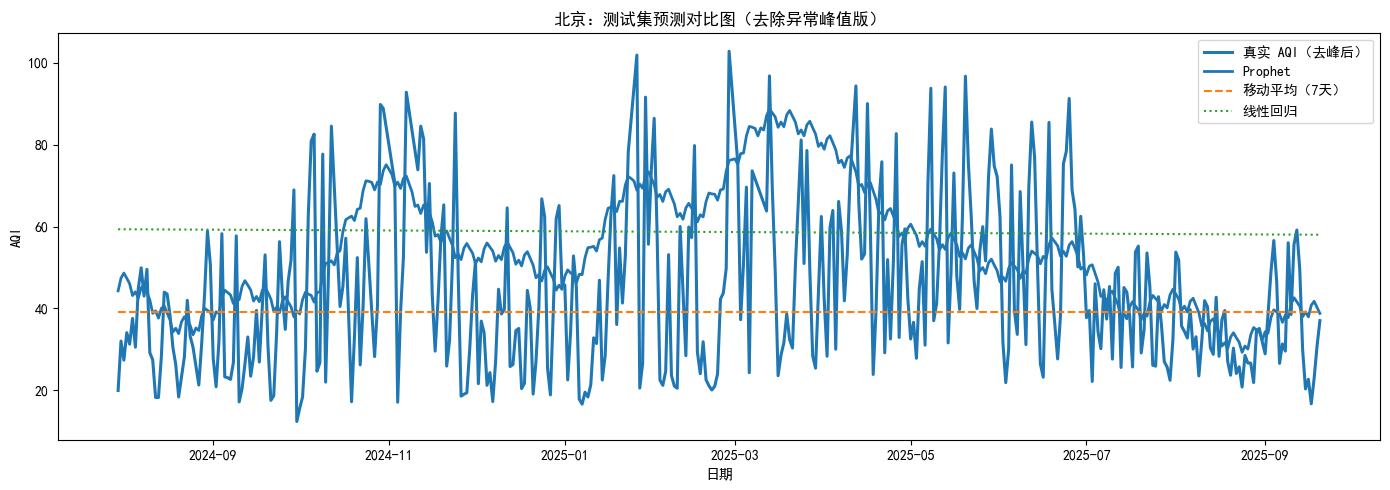

In [ ]:
# 可视化（新行）：使用上一单元处理后的结果单独画图
plt.figure(figsize=(14, 5))
plt.plot(plot_df["date"], plot_df["AQI"], label="真实 AQI（原始）", color="#4e79a7", alpha=0.35, linewidth=1.5)
plt.plot(plot_df["date"], plot_df["AQI_denoised"], label="真实 AQI（去峰后）", color="#1f77b4", linewidth=2.2)
plt.plot(plot_df["date"], plot_df["Prophet"], label="Prophet", linewidth=2)
plt.plot(plot_df["date"], plot_df["MovingAverage7d"], label="移动平均（7天）", linestyle="--")
plt.plot(plot_df["date"], plot_df["LinearRegression"], label="线性回归", linestyle=":")

plt.title(f"{CITY}：测试集预测对比图（去除异常峰值版）")
plt.xlabel("日期")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()